Tutorial 10 Ensemble Learning:

In [7]:
pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


1.We are going to work on spambase dataset, where the normalized frequency of different words in an email are recorded, based on which an email is labeled as spam (1) or not spam (0)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2.Read dataset “spambase.csv”.

In [9]:
df = pd.read_csv("spambase.csv")

3.Split the data into a train and test set.

In [10]:
X = df.iloc[:, :-1]  
y = df.iloc[:, -1] 

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4.Implement Bagging using Random Forest Algorithm.

In [13]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.9555


5.Implement Boosting using Adaboost Algorithm.

In [15]:
adaboost_classifier = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_classifier.fit(X_train, y_train)
y_pred_ada = adaboost_classifier.predict(X_test)
ada_accuracy = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")

AdaBoost Accuracy: 0.9370


In [16]:
# Print Accuracy Scores
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"AdaBoost Accuracy: {accuracy_ab:.4f}")

Random Forest Accuracy: 0.9555
AdaBoost Accuracy: 0.9370


In [17]:
# Step 6: Print Classification Reports
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nAdaBoost Classification Report:\n", classification_report(y_test, y_pred_ab))


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       531
           1       0.98      0.92      0.95       390

    accuracy                           0.96       921
   macro avg       0.96      0.95      0.95       921
weighted avg       0.96      0.96      0.96       921


AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       531
           1       0.95      0.90      0.92       390

    accuracy                           0.94       921
   macro avg       0.94      0.93      0.94       921
weighted avg       0.94      0.94      0.94       921



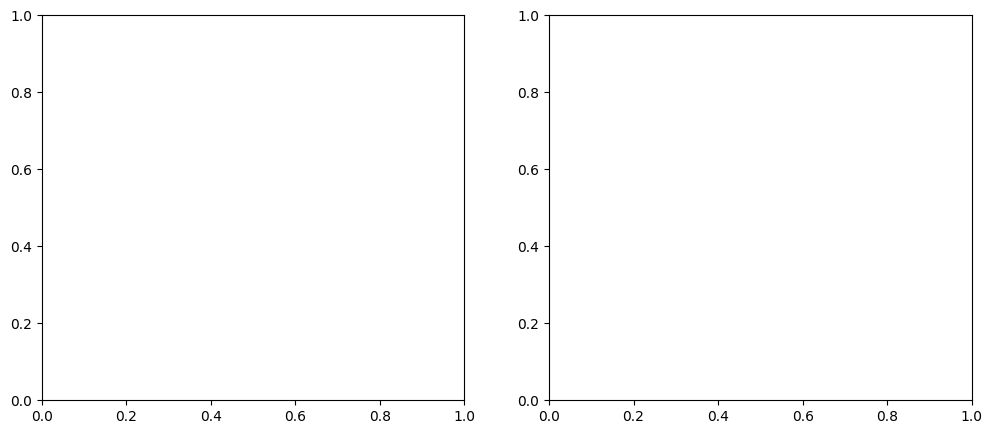

In [18]:
# Step 7: Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

In [19]:
# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

Text(120.72222222222221, 0.5, 'Actual')

In [20]:

# AdaBoost Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_ab), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title("AdaBoost Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.show()

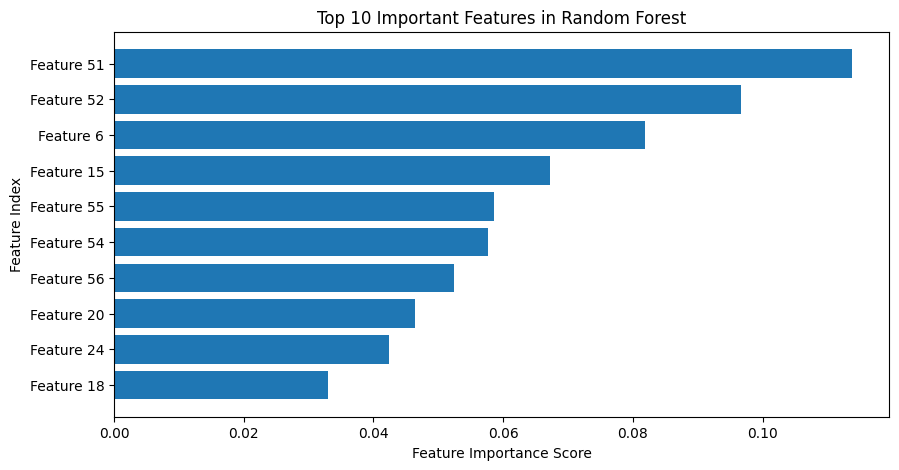

In [21]:
# Step 8: Feature Importance (Random Forest)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [f"Feature {i}" for i in indices])
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Index")
plt.title("Top 10 Important Features in Random Forest")
plt.show()